# 임베딩 내 편향성 알아보기

- 주어진 영화 코퍼스를 바탕으로 워드임베딩 모델 만들기  
&rarr; 워드임베딩의 most_similar() 메소드 결과가 의미상 바르게 나왔다.

- 영화 구분, 장르별로 target, attribute에 대한 대표성있는 단어 셋을 생성하기  
&rarr; 타당한 방법론을 통해 중복이 잘 제거되고 개념축을 의미적으로 잘 대표하는 단어 셋이 만들어졌다.

- WEAT score 계산 및 시각화하기  
&rarr; 전체 영화 장르별로 예술/일반 영화에 대한 편향성 WEAT score가 상식에 부합하는 수치로 얻어졌으며 이를 잘 시각화하였다.


## 0. 라이브러리 import 및 필요한 설정

In [1]:
from gensim.models import Word2Vec, FastText
from sklearn.feature_extraction.text import TfidfVectorizer

import numpy as np
from numpy.linalg import norm
from konlpy.tag import Okt

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import os
import glob
import pickle

In [2]:
DATA_PATH = "./weat_data/"

In [3]:
# txt 파일 경로
TXT_PATH = glob.glob(DATA_PATH + '*.txt')
print(TXT_PATH)

['./weat_data/synopsis_gen.txt', './weat_data/synopsis_SF.txt', './weat_data/synopsis_action.txt', './weat_data/synopsis_etc.txt', './weat_data/synopsis_adventure.txt', './weat_data/synopsis_romance.txt', './weat_data/synopsis_western.txt', './weat_data/synopsis_family.txt', './weat_data/synopsis_fantasy.txt', './weat_data/synopsis_documentary.txt', './weat_data/synopsis_horror.txt', './weat_data/synopsis_comedy.txt', './weat_data/synopsis.txt', './weat_data/synopsis_crime.txt', './weat_data/synopsis_animation.txt', './weat_data/synopsis_historical.txt', './weat_data/synopsis_war.txt', './weat_data/synopsis_adult.txt', './weat_data/synopsis_mystery.txt', './weat_data/synopsis_show.txt', './weat_data/synopsis_thriller.txt', './weat_data/synopsis_musical.txt', './weat_data/synopsis_art.txt', './weat_data/synopsis_drama.txt']


In [4]:
# 장르 이름
file_list = os.listdir(DATA_PATH)
txt_names = [file.split(".")[0] for file in file_list if file.endswith(".txt")]
GENRE_NAME = [txt_name.split("_")[-1] for txt_name in txt_names]
print(GENRE_NAME)
print(len(GENRE_NAME))

['gen', 'SF', 'action', 'etc', 'adventure', 'romance', 'western', 'family', 'fantasy', 'documentary', 'horror', 'comedy', 'synopsis', 'crime', 'animation', 'historical', 'war', 'adult', 'mystery', 'show', 'thriller', 'musical', 'art', 'drama']
24


In [5]:
# 임베딩 만들 파일, target 파일, attribute 파일 경로 분리 
DATA_DICT = {
    'embedding':{'path':[], 'name': []},
    'target': {'path':[], 'name': []},
    'attribute': {'path':[], 'name': []}
}

In [6]:
for f_path, f_name in zip(TXT_PATH, GENRE_NAME):
    if f_name == "synopsis":
        DATA_DICT['embedding']['path'] = f_path
        DATA_DICT['embedding']['name'] = f_name
    elif f_name in ['art', 'gen']:
        DATA_DICT['target']['path'].append(f_path)
        DATA_DICT['target']['name'].append(f_name)
    else:
        DATA_DICT['attribute']['path'].append(f_path)
        DATA_DICT['attribute']['name'].append(f_name)      

In [7]:
print(DATA_DICT['embedding'])
print(DATA_DICT['target'])
print(DATA_DICT['attribute']['path'])
print(len(DATA_DICT['attribute']['path']))
print(DATA_DICT['attribute']['name'])
print(len(DATA_DICT['attribute']['name']))

{'path': './weat_data/synopsis.txt', 'name': 'synopsis'}
{'path': ['./weat_data/synopsis_gen.txt', './weat_data/synopsis_art.txt'], 'name': ['gen', 'art']}
['./weat_data/synopsis_SF.txt', './weat_data/synopsis_action.txt', './weat_data/synopsis_etc.txt', './weat_data/synopsis_adventure.txt', './weat_data/synopsis_romance.txt', './weat_data/synopsis_western.txt', './weat_data/synopsis_family.txt', './weat_data/synopsis_fantasy.txt', './weat_data/synopsis_documentary.txt', './weat_data/synopsis_horror.txt', './weat_data/synopsis_comedy.txt', './weat_data/synopsis_crime.txt', './weat_data/synopsis_animation.txt', './weat_data/synopsis_historical.txt', './weat_data/synopsis_war.txt', './weat_data/synopsis_adult.txt', './weat_data/synopsis_mystery.txt', './weat_data/synopsis_show.txt', './weat_data/synopsis_thriller.txt', './weat_data/synopsis_musical.txt', './weat_data/synopsis_drama.txt']
21
['SF', 'action', 'etc', 'adventure', 'romance', 'western', 'family', 'fantasy', 'documentary', 'ho

## 1. 형태소 분석기로 명사 추출

In [8]:
# 명사 추출 및 토크나이징 함수
def make_noun_token(file_path, tokenizer):
    '''
    output: [[tok1, tok2, ...], [tok1, tok2, ...]] (문장 단위로 토큰 저장)
    '''
    tokens = []
    with open(file_path, 'r') as f:
        print(file_path, "파일을 읽고 있습니다.")
        while True:            
            line = f.readline()
            if not line: break
            tokenlist = tokenizer.pos(line, stem=True, norm=True)
            res = []
            for w in tokenlist:
                if w[1] in ['Noun']:
                    res.append(w[0])
            tokens.append(res)
    return tokens

In [9]:
# 문장 단위로 저장됐던 토큰을 합쳐서 문서 단위로 만들어 주는 함수
def merge_tokens(token_list):
    flat_tokens = [word for sentence in token_list for word in sentence]
    merged_tokens = " ".join(flat_tokens)
    return merged_tokens

In [10]:
# 재사용을 위해 token 저장하는 함수
def save_tokens(tokens, file_name):
    with open(file_name, 'wb') as f:
        pickle.dump(tokens, f, pickle.HIGHEST_PROTOCOL)

In [11]:
# 저장한 token을 불러오는 함수
def load_tokens(file_name):
    with open(file_name, 'rb') as f:
        tokens = pickle.load(f)
        return tokens

### 1.1 word embedding의 재료가 되는 synopsis 문서 토큰화 및 명사 추출

In [12]:
# tokens_synop = make_noun_token(DATA_DICT['embedding']['path'])

In [13]:
# print(len(tokens_synop))
# print(tokens_synop[:10])
# print(tokens_synop[-10:])

In [14]:
# save_tokens(tokens_synop, 'tokens_synop.pickle')

In [15]:
# 만들어 놨던 token을 불러와서 사용
tokens_synop = load_tokens('tokens_synop.pickle')
print(len(tokens_synop))

71156


### 1.2 target 단어를 얻기 위한 토큰화 및 명사 추출

In [16]:
tokens_target = {f_name: [] for f_name in DATA_DICT['target']['name']}
tokens_target

{'gen': [], 'art': []}

In [17]:
# for f_path, f_name in zip(DATA_DICT['target']['path'], DATA_DICT['target']['name']):
#     tokens = make_noun_token(f_path)
#     tokens_target[f_name] = tokens

In [18]:
# # 재사용을 위해 토큰 저장
# save_tokens(tokens_target, 'tokens_target.pickle')

In [19]:
# 만들어 놨던 token을 불러와서 사용
tokens_target = load_tokens('tokens_target.pickle')
print(len(tokens_target))
print(len(tokens_target['art']))
print(len(tokens_target['gen']))

2
14435
48116


### 1.3 attribute 단어를 얻기 위한 토큰화 및 명사 추출

In [20]:
tokens_attr = {f_name: [] for f_name in DATA_DICT['attribute']['name']}
print(tokens_attr)
print(len(tokens_attr))

{'SF': [], 'action': [], 'etc': [], 'adventure': [], 'romance': [], 'western': [], 'family': [], 'fantasy': [], 'documentary': [], 'horror': [], 'comedy': [], 'crime': [], 'animation': [], 'historical': [], 'war': [], 'adult': [], 'mystery': [], 'show': [], 'thriller': [], 'musical': [], 'drama': []}
21


In [21]:
# for f_path, f_name in zip(DATA_DICT['attribute']['path'], DATA_DICT['attribute']['name']):
#     tokens = make_noun_token(f_path)
#     tokens_attr[f_name] = tokens

In [22]:
# # 재사용을 위해 토큰 저장
# save_tokens(tokens_attr, 'tokens_attr.pickle')

In [23]:
# 만들어 놨던 token을 불러와서 사용
tokens_attr = load_tokens('tokens_attr.pickle')
print(len(tokens_attr))
print(len(tokens_attr['SF']))
print(len(tokens_attr['drama']))

21
1023
19229


## 2. word embedding 만들기

In [24]:
# 최소 10번 이상 등장한 단어들을 사용 (min_count=10)
model_w2v = Word2Vec(sentences=tokens_synop, sg=1, vector_size=128, min_count=10)

In [25]:
# wor2vec은 시놉시스 안에서 등장할 수 있는 단어도 어휘사전에 없다면 OOV로 인식될 수 있음
print(model_w2v.wv.most_similar("자동차"))
print(model_w2v.wv.most_similar("배우"))
print(model_w2v.wv.most_similar("피습"))

[('오토바이', 0.76787269115448), ('도로', 0.7458483576774597), ('자전거', 0.71391761302948), ('승용차', 0.7043410539627075), ('벽돌', 0.6996093392372131), ('기름', 0.6920560002326965), ('가다가', 0.6850928068161011), ('안테나', 0.6837761402130127), ('주행', 0.6801900267601013), ('선로', 0.679661750793457)]
[('여배우', 0.7797480821609497), ('주연', 0.7499442100524902), ('연기자', 0.7423840761184692), ('캐스팅', 0.7317532896995544), ('연기', 0.7242231369018555), ('배역', 0.7215657830238342), ('출연', 0.7137442827224731), ('영화감독', 0.7012268900871277), ('신인', 0.6972047090530396), ('무명', 0.687539279460907)]


KeyError: "Key '피습' not present in vocabulary"

In [26]:
# word2vec보다 OOV에 강건하고 미세한 의미 정보까지 포착 가능한 faxtText 모델로 임베딩 추출
# 최소 10번 이상 등장한 단어들을 사용 (min_count=10)
model_ft = FastText(sentences=tokens_synop, sg=1, vector_size=128, min_count=10)

In [27]:
print(model_ft.wv.most_similar("자동차"))
print(model_ft.wv.most_similar("배우"))
print(model_ft.wv.most_similar("피습"))

[('자동', 0.8106819987297058), ('오토바이', 0.76075679063797), ('도로', 0.720564067363739), ('승용차', 0.7034399509429932), ('타고', 0.688183605670929), ('안테나', 0.6836804747581482), ('운전자', 0.6776295900344849), ('컨테이너', 0.6775936484336853), ('주행', 0.6771456599235535), ('고속도로', 0.6758193969726562)]
[('여배우', 0.8085465431213379), ('연기자', 0.7640908360481262), ('영화배우', 0.7412525415420532), ('연극배우', 0.7322341799736023), ('영화감독', 0.7190219163894653), ('남자배우', 0.7180894017219543), ('주연', 0.7172699570655823), ('연기력', 0.7076937556266785), ('캐스팅', 0.7027443647384644), ('연기', 0.6859847903251648)]
[('사태', 0.21508601307868958), ('지진', 0.20041583478450775), ('빙하', 0.2004081755876541), ('우려', 0.1947384774684906), ('재앙', 0.18877828121185303), ('폐쇄', 0.18844422698020935), ('야생', 0.18752680718898773), ('방사', 0.1872725486755371), ('닥치', 0.18592660129070282), ('감지', 0.18280676007270813)]


## 3. 단어 세트 설정

In [28]:
def remove_duplicates(w1, w2, model, vectorizer, n=15):
    n_words = n
    w1_, w2_ = [], []
    for i in range(100):
        w1_.append(vectorizer.get_feature_names_out()[w1[i][0]])
        w2_.append(vectorizer.get_feature_names_out()[w2[i][0]])

    # w1에만 있는 15개
    target_w1, target_w2 = [], []
    for i in range(100):
        if (w1_[i] not in w2_) and (w1_[i] in model.wv): target_w1.append(w1_[i])
        if len(target_w1) == n: break

    for i in range(100):
        if (w2_[i] not in w1_) and (w2_[i] in model.wv): target_w2.append(w2_[i])
        if len(target_w2) == n: break
    
    return target_w1, target_w2

### 3.1 TF-IDF

#### 3.1.1 target 단어에 대한 선정

In [29]:
# TF-IDF 적용하기 위해서는 토큰을 한 문장으로 합쳐줘야 함
art_tokens = merge_tokens(tokens_target['art'])
gen_tokens = merge_tokens(tokens_target['gen'])
print(len(art_tokens))
print(len(gen_tokens))

620208
3014815


In [30]:
# art, gen 2개 문서에 대해 TF-IDF 값 계산
target_vectorizer = TfidfVectorizer()
target_X = target_vectorizer.fit_transform([art_tokens, gen_tokens])
print(target_X.shape)

(2, 41082)


In [31]:
# 각 문서에 해당하는 tf-idf의 sparse vector, 내부에는 좌표만 저장하도록 하여 메모리 아낌
m1 = target_X[0].tocoo()
m2 = target_X[1].tocoo()

# 각 문서가 갖고 있는 단어 index와 TF-IDF 값
w1 = [[i,j] for i,j in zip(m1.col, m1.data)]
w2 = [[i,j] for i,j in zip(m2.col, m2.data)]
# TF-IDF 값 기준 내림차순 정렬 -> 중요한 단어가 먼저 나오게
w1.sort(key=lambda x: x[1], reverse=True)
w2.sort(key=lambda x: x[1], reverse=True)

In [32]:
print('예술 영화를 대표하는 단어들: ')
for i in range(20):
    print(target_vectorizer.get_feature_names_out()[w1[i][0]], end=', ')
print()
print('일반 영화를 대표하는 단어들: ')
for i in range(20):
    print(target_vectorizer.get_feature_names_out()[w2[i][0]], end=', ')

예술 영화를 대표하는 단어들: 
그녀, 자신, 시작, 위해, 사랑, 사람, 영화, 친구, 남자, 가족, 이야기, 마을, 사건, 마음, 세상, 아버지, 아이, 엄마, 모든, 여자, 
일반 영화를 대표하는 단어들: 
자신, 그녀, 영화제, 위해, 사람, 시작, 국제, 영화, 친구, 사랑, 남자, 이야기, 대한, 서울, 여자, 사건, 남편, 아이, 가족, 아버지, 

In [33]:
# 두 문서에서 중복해서 나오는 단어를 제거
art_words, gen_words = remove_duplicates(w1, w2, model_ft, target_vectorizer, n=15)

In [34]:
print('예술 영화를 대표하는 단어들: ')
print(art_words)
print('일반 영화를 대표하는 단어들: ')
print(gen_words)

예술 영화를 대표하는 단어들: 
['아빠', '음악', '결심', '운명', '지금', '여인', '이름', '이후', '준비', '감정', '만난', '처음', '충격', '누구', '그린']
일반 영화를 대표하는 단어들: 
['서울', '애니메이션', '여성', '가지', '주인공', '대해', '연출', '사회', '다큐멘터리', '부문', '섹스', '바로', '의도', '계획', '정체']


#### 3.1.2 attribute 단어에 대한 선정

In [35]:
# TF-IDF 적용하기 위해서는 토큰을 한 문장으로 합쳐줘야 함
genre_merged_tokens = {}

for name, tokens in tokens_attr.items():    
    genre_merged_tokens[name] = merge_tokens(tokens)

print(len(genre_merged_tokens))
print(len(genre_merged_tokens['SF']))
print(len(genre_merged_tokens['drama']))

21
65038
1124761


In [36]:
# TF-IDF 모델에 입력으로 들어가도록 token만 따로 할당
genre_inputs = [tokens for tokens in genre_merged_tokens.values()]
print(len(genre_inputs))
print(len(genre_inputs[0]))
print(len(genre_inputs[-1]))

21
65038
1124761


In [37]:
genre_vectorizer = TfidfVectorizer()
genre_x = genre_vectorizer.fit_transform(genre_inputs)
print(genre_x.shape)

(21, 42191)


In [38]:
# sparse vector에 21개 장르 각각의 index, TF-IDF 값을 담음
genre_m = [genre_x[i].tocoo() for i in range(genre_x.shape[0])]
genre_w = [[[i,j] for i,j in zip(mm.col, mm.data)] for mm in genre_m]

# TF-IDF 값이 높은 순서대로 sorting
for i in range(len(genre_w)):
    genre_w[i].sort(key=lambda x: x[1], reverse=True)

In [39]:
# 21개 장르를 대표하는 단어 예시 출력
attributes = []
for i in range(len(genre_inputs)):
    print(list(genre_merged_tokens.keys())[i], end=": ")
    attr = []
    j = 0
    while (len(attr)<15):
        if genre_vectorizer.get_feature_names_out()[genre_w[i][j][0]] in model_ft.wv:
            attr.append(genre_vectorizer.get_feature_names_out()[genre_w[i][j][0]])
            print(genre_vectorizer.get_feature_names_out()[genre_w[i][j][0]], end=", ")
        j+=1
    attributes.append(attr)
    print()                  

SF: 위해, 자신, 지구, 시작, 사람, 인류, 인간, 미래, 우주, 그녀, 로봇, 세계, 모든, 박사, 우주선, 
action: 위해, 자신, 시작, 조직, 사건, 사람, 그녀, 경찰, 전쟁, 모든, 목숨, 사실, 친구, 가족, 요원, 
etc: 영화제, 국제, 서울, 단편, 영화, 자신, 사람, 이야기, 그녀, 남자, 위해, 시작, 사랑, 뉴미디어, 페스티벌, 
adventure: 위해, 자신, 시작, 친구, 마을, 아버지, 영화, 아이, 사람, 여행, 세계, 앤트, 세상, 가족, 모험, 
romance: 그녀, 사랑, 자신, 시작, 남편, 남자, 여자, 사람, 친구, 섹스, 위해, 마음, 결혼, 서로, 아내, 
western: 서부, 보안관, 위해, 벌린, 카우보이, 그레이프바인, 헨리, 마을, 자신, 개릿, 아이, 시작, 에머슨, 무법자, 프린트, 
family: 엄마, 아빠, 가족, 영화제, 자신, 위해, 친구, 아주르, 아버지, 시작, 그녀, 아들, 마을, 국제, 낙타, 
fantasy: 자신, 그녀, 시작, 위해, 사람, 사랑, 요괴, 영화제, 이야기, 영화, 소녀, 남자, 인간, 세상, 마을, 
documentary: 영화제, 영화, 다큐, 국제, 다큐멘터리, 사람, 이야기, 대한, 자신, 감독, 위해, 서울, 우리, 시작, 세계, 
horror: 시작, 위해, 사람, 자신, 친구, 그녀, 사건, 공포, 발견, 죽음, 마을, 가족, 악령, 남자, 좀비, 
comedy: 그녀, 자신, 시작, 위해, 사랑, 사람, 친구, 영화, 남자, 여자, 영화제, 가족, 과연, 마을, 사건, 
crime: 사건, 위해, 자신, 경찰, 시작, 그녀, 범죄, 조직, 살인, 사람, 마약, 형사, 남자, 모든, 살해, 
animation: 애니메이션, 국제, 영화제, 친구, 인디애니페스트, 위해, 자신, 시작, 사람, 페스티벌, 서울, 이야기, 아이, 마을, 소녀, 
historical: 조선, 위해, 시작, 신기전, 사랑, 자신, 아가멤논, 황제, 그녀, 루안, 최

## 4. WEAT score 계산과 시각화

### 4.1 WEAT score 계산 함수 정의

In [40]:
def cos_sim(i, j):
    return np.dot(i, j.T) / (norm(i)*norm(j))

In [41]:
def s(w, A, B):
    c_a = cos_sim(w, A)
    c_b = cos_sim(w, B)
    mean_a = np.mean(c_a, axis=-1)
    mean_b = np.mean(c_b, axis=-1)
    return mean_a - mean_b

In [42]:
def weat_score(X, Y, A, B):
    s_x = s(X, A, B)
    s_y = s(Y, A, B)

    mean_x = np.mean(s_x)
    mean_y = np.mean(s_y)

    std_dev = np.std(np.concatenate([s_x, s_y], axis=0))

    return (mean_x-mean_y)/std_dev

### 4.2 WEAT 계산

In [43]:
matrix = [[0 for _ in range(len(genre_inputs))] for _ in range(len(genre_inputs))]
print(len(matrix))

21


In [44]:
# target인 art 관련 단어와 gen 관련 단어를 X, Y에 numpy array 형태로 할당
X = np.array([model_ft.wv[word] for word in art_words])
Y = np.array([model_ft.wv[word] for word in gen_words])
print(X.shape)

(15, 128)


In [45]:
# 21개의 장르에 대해 WEAT score 계산
for i in range(len(genre_inputs)-1): # 0~19
    for j in range(i+1, len(genre_inputs)): # 1~20
        A = np.array([model_ft.wv[word] for word in attributes[i]])
        B = np.array([model_ft.wv[word] for word in attributes[j]])
        # print(A.shape)
        matrix[i][j] = weat_score(X,Y,A,B)

In [46]:
DATA_DICT['target'].keys()

dict_keys(['path', 'name'])

In [47]:
genre_name = list(genre_merged_tokens.keys())

for i in range(len(genre_name)-1): # 0~19
    for j in range(i+1, len(genre_name)): # 1~20
        if matrix[i][j] > 0.8:
            print(genre_name[i], genre_name[j], matrix[i][j])
            print(f"해석: {genre_name[i]}가 {genre_name[j]}보다 상대적으로, art 분야에 더 가깝다.")                  
        # i가 x와 더 거리가 가까움
        elif matrix[i][j] < -0.8:
            print(genre_name[i], genre_name[j], matrix[i][j])
            print(f"해석: {genre_name[j]}가 {genre_name[i]}보다 상대적으로, art 분야에 더 가깝다.")

SF documentary 0.8066492
해석: SF가 documentary보다 상대적으로, art 분야에 더 가깝다.
action documentary 0.84592533
해석: action가 documentary보다 상대적으로, art 분야에 더 가깝다.
etc romance -0.81073177
해석: romance가 etc보다 상대적으로, art 분야에 더 가깝다.
etc western -0.85112906
해석: western가 etc보다 상대적으로, art 분야에 더 가깝다.
etc family -0.84542596
해석: family가 etc보다 상대적으로, art 분야에 더 가깝다.
etc horror -0.80126154
해석: horror가 etc보다 상대적으로, art 분야에 더 가깝다.
etc historical -0.8599644
해석: historical가 etc보다 상대적으로, art 분야에 더 가깝다.
etc show -1.0063335
해석: show가 etc보다 상대적으로, art 분야에 더 가깝다.
etc drama -0.8823811
해석: drama가 etc보다 상대적으로, art 분야에 더 가깝다.
adventure documentary 1.004332
해석: adventure가 documentary보다 상대적으로, art 분야에 더 가깝다.
romance documentary 0.9376978
해석: romance가 documentary보다 상대적으로, art 분야에 더 가깝다.
romance crime 0.8005072
해석: romance가 crime보다 상대적으로, art 분야에 더 가깝다.
romance animation 0.8133729
해석: romance가 animation보다 상대적으로, art 분야에 더 가깝다.
romance adult 0.8067955
해석: romance가 adult보다 상대적으로, art 분야에 더 가깝다.
western documentary 1.0005562
해석: weste

$$\frac{\text{mean}_{x \in X} s(x, A, B) - \text{mean}_{y \in Y} s(y, A, B)}{\text{std}_{w \in X \cup Y} s(w, A, B)}$$

해석 방법: 
- 양수면서 2에 가까우면, x target(art)가 A 장르에 상대적으로 더 가까움
- 음수면서 -2에 가까우면, y target(gen)이 B 장르에 상대적으로 더 가까움

예측
- 상업 영화(Gen) 편향: 액션(action), 범죄(crime), 스릴러(thriller) 등은 주로 관객의 말초적 흥미를 유발하여 상업 영화(gen)에 가까울 것으로 보임

- 예술 영화(Art) 편향: 드라마(drama), 다큐멘터리(documentary) 등은 격동적인 재미와는 다른, 추상적이고 내면적인 주제를 다루는 예술 영화(art)와 더 높은 유사도를 가질 것으로 보임

In [49]:
def get_idx(genre_word):
    return genre_name.index(genre_word)

In [50]:
group1 = ['action', 'crime', 'thriller']
group2 = ['drama', 'documentary']
group1_idx = [get_idx(genre_word) for genre_word in group1]
group2_idx = [get_idx(genre_word) for genre_word in group2]

print(group1_idx)
print(group2_idx)

[1, 11, 18]
[20, 8]


In [53]:
for i in group1_idx: # 1, 11, 18
    for j in group2_idx: # 20, 8
        print(genre_name[i], genre_name[j], matrix[i][j])       

action drama 0.33916068
action documentary 0.84592533
crime drama 0.13276902
crime documentary 0
thriller drama 0.4788445
thriller documentary 0


결과:  
- drama나 documentary가 art에 더 가까울 것 같았는데 반대 결과가 나왔음
- thriller도 drama 보다는 art 분야에 상대적으로 가깝게 위치하는 것을 확인함
- 다른 경우에는 명확하게 편차가 나타나지 않는 것으로 보임

### 4.3 시각화

In [54]:
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

/home/minkyujeong/anaconda3/envs/nlp_cv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()
/home/minkyujeong/anaconda3/envs/nlp_cv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


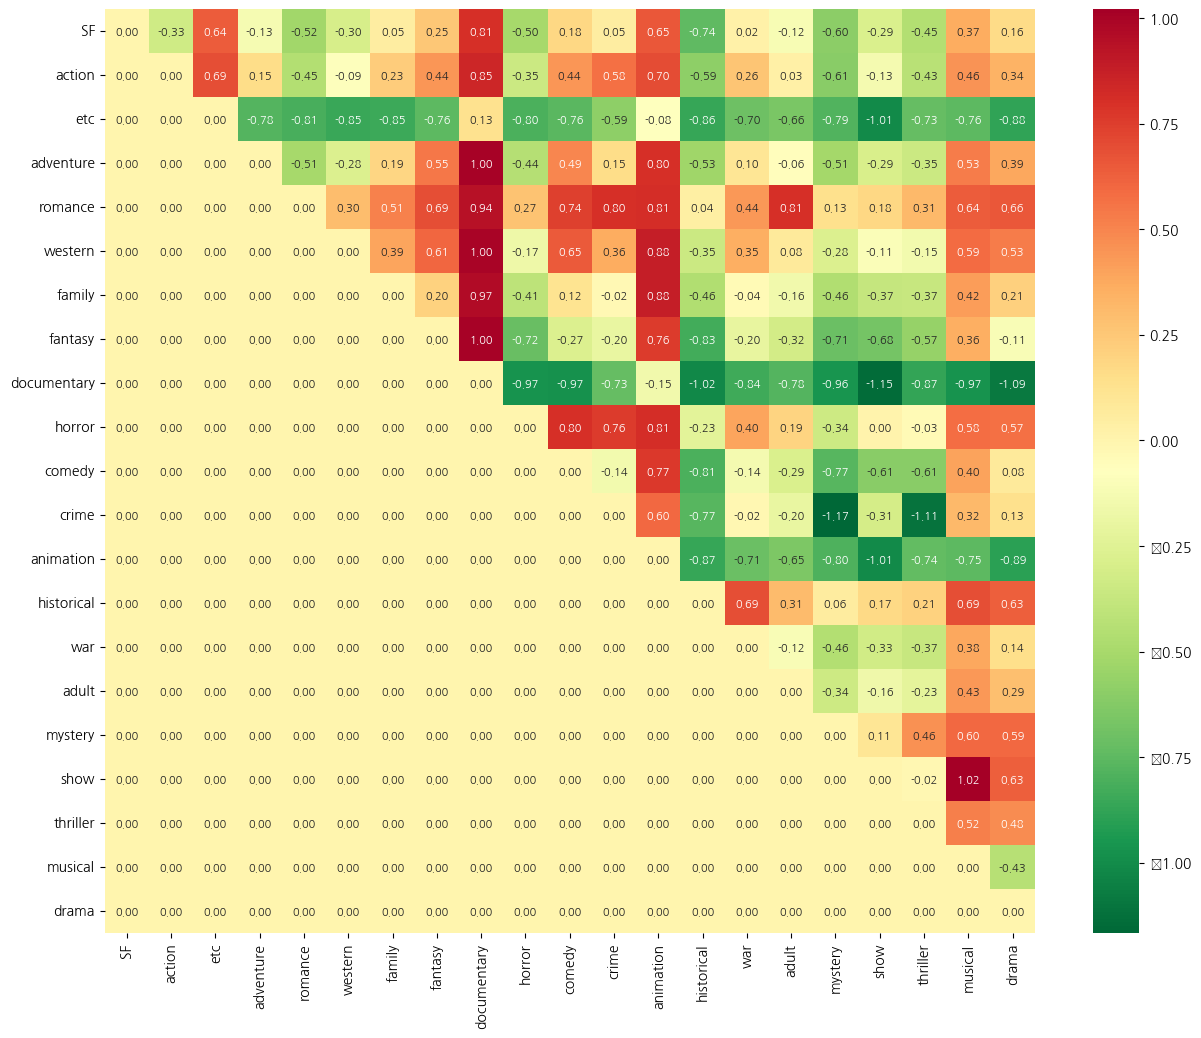

In [55]:
# 1. 캔버스 크기 설정 (가로 15인치, 세로 12인치)
plt.figure(figsize=(15, 12))

# 2. 히트맵 그리기
ax = sns.heatmap(matrix, 
                 xticklabels=genre_name, 
                 yticklabels=genre_name, 
                 annot=True, 
                 fmt='.2f',      # 소수점 둘째 자리까지 표시 (글자 겹침 방지)
                 annot_kws={"size": 8}, # 숫자 글자 크기 조절
                 cmap='RdYlGn_r')

plt.show()

해석: 
- 빨강: 양수이면서 2에 가깝다는 것은 row에 위치한 장르가 column에 위치한 장르보다 상대적으로 예술 분야에 더 가깝다.
- 초록: 음수이면서 -2에 가깝다는 것은 column에 위치한 장르가 row에 위치한 장르보다 상대적으로 예술 분야에 더 가깝다.

## 5. 개선 시도

TF-IDF 적용 시 아래와 같은 문제 발생 가능

- 고유명사 과대적합: TF-IDF는 '특정 문서에 자주 나오지만, 전체 문서에서는 희귀한 단어'에 가장 높은 점수를 부여하므로, 영화 시놉시스에서는 주인공 이름이나 특정 지역명 등에 점수를 높게 부여할 수 있음 

- 장르 간 의미적 중복: '추격', '살인', '총' 같은 단어는 액션, 스릴러, 범죄 장르 등 여러 곳에서 동시에 중요하게 다뤄짐 TF-IDF 점수만으로 상위 N개를 자르면 각 장르의 대표 단어들이 서로 겹치게 되어 변별력이 떨어질 수 있음

개선 방안

TF-IDF의 장점(통계적 중요도)은 살리되 위 문제들을 해결하기 위해 **하이퍼 파라미터 튜닝 + 계층적 차집합 연산**을 시도할 수 있음

- min_df 조절을 통한 이름 제거: min_df 값을 지정해서 (최소 n개 이상의 장르 문서에서 등장), 주인공 이름이나 하나의 영화(문서)에만 등장하는 단어를 제외

- max_df 조절을 통한 범용어 제거: max_df=0.7로 설정하여, 모든 장르에 흔하게 등장하는 단어를 제외

- 계층적 차집합(Set Difference) 적용: * 21개 장르(Attribute): 각 장르의 상위 키워드에서 다른 장르들의 상위 키워드를 차집합하여 '오직 해당 장르에서만 두드러지는' 고유 단어를 남김

In [73]:
# whole_inputs = genre_inputs + [art_tokens, gen_tokens]

In [82]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. TF-IDF 벡터라이저 설정 (고유명사 및 범용어 1차 필터링)
# 최소 2개 이상의 문서에 등장(이름 제거), 70% 이하 문서에 등장(범용어 제거)
vectorizer = TfidfVectorizer(max_df=0.6, min_df=2)
X = vectorizer.fit_transform(genre_inputs)
feature_names = vectorizer.get_feature_names_out()

# 2. 각 문서(21개)의 상위 100개 TF-IDF 단어를 추출하는 함수
def get_top_tfidf_words(doc_idx, top_n=100):
    row = X[doc_idx].tocoo()
    sorted_indices = np.argsort(row.data)[::-1]
    
    words = []
    for idx in sorted_indices:
        word = feature_names[row.col[idx]]
        # FastText 모델에 존재하고, 2글자 이상인 단어만 취합
        if word in model_ft.wv and len(word) >= 2:
            words.append(word)
        if len(words) >= top_n:
            break
    return words

# 모든 문서의 상위 100개 단어를 딕셔너리에 저장
top_words_dict = {i: get_top_tfidf_words(i, 100) for i in range(21)}


# 3. 중복 제거 (계층적 차집합 연산 적용)

print("=== [최종] 21개 장르 대표 단어 (차집합 적용) ===")
final_attributes = []
genre_names = list(genre_merged_tokens.keys())

for i in range(21):
    my_words = top_words_dict[i]
    
    # 나를 제외한 다른 20개 장르의 상위 40개 단어를 합집합으로 모음
    # (너무 많이 빼면 단어가 다 사라지므로 상위 40개 정도만 뺌)
    others_words = set()
    for j in range(21):
        if i != j:
            others_words.update(top_words_dict[j][:40])
            
    # 차집합: 내 상위 100개 단어 중, 다른 장르의 최상위권에 없는 단어만 남김
    unique_words = [w for w in my_words if w not in others_words]
    
    # 그 중 상위 15개 추출
    final_attr = unique_words[:15]
    final_attributes.append(final_attr)
    print(f"{genre_names[i]}: {final_attr}")

print("\n=== [최종] 타겟(Art vs Gen) 대표 단어 (차집합 적용) ===")
# art_words = top_words_dict[21]
# gen_words = top_words_dict[22]

# Art와 Gen 서로 간에만 차집합을 수행하여 대조적 특징 극대화
final_art = [w for w in art_words if w not in gen_words][:15]
final_gen = [w for w in gen_words if w not in art_words][:15]

print(f"Art: {final_art}")
print(f"Gen: {final_gen}")

=== [최종] 21개 장르 대표 단어 (차집합 적용) ===
SF: ['스타크', '리플리', '컨트', '수퍼맨', '상어', '물체', '진화', '수트', '히노키', '섹터', '멸망', '유성', '토네이도', '군단', '강두']
action: ['테러리스트', '특수부대', '닌자', '암살자', '야쿠자', '정예', '케인', '파이터', '강호', '카이', '반격', '지진', '청부', '격투기', '마약상']
etc: ['뉴미디어', '메트로', '실험영화', '디지털', '독도', '재연', '사물', '언어', '지현', '사운드', '관점', '퍼포먼스', '준희', '발달장애', '포르투갈']
adventure: ['옥자', '원주민', '윈치', '펠레', '크루소', '양말', '루카스', '썰매개', '알라딘', '앵거스', '십자군', '누크', '국새', '슈퍼악당', '휴고']
romance: ['시아버지', '형부', '형수', '미연', '펜션', '수진', '하숙집', '주희', '준석', '처제', '정식', '정우', '스와핑', '준영', '미란']
western: ['벌린', '카우보이', '개릿', '무법자', '프린트', '태구', '마적', '랜던', '버질', '스탠리', '교수형', '만도', '듀발', '장고', '총잡이']
family: ['낙타', '동구', '펠리칸', '벤트', '케이시', '혜지', '유나', '테리', '번개', '그레고리', '파코', '아스', '제노', '펠릭스', '주니']
fantasy: ['순영', '차사', '니모', '왕비', '덤블도어', '저승', '대인', '신들', '에바', '거인', '기사단', '아미', '마리나', '바이', '수염']
documentary: ['인디다큐페스티발', '등반', '인권영화제', '건축사', '공동체', '세월호', '이주', '산악', '난민', '노동', '팔레스타인', '인권', '증언', '농민', '농성

In [84]:
len(final_attributes)

21

In [85]:
new_matrix = [[0 for _ in range(len(final_attributes))] for _ in range(len(final_attributes))]
print(len(new_matrix))

21


In [86]:
# target인 art 관련 단어와 gen 관련 단어를 X, Y에 numpy array 형태로 할당
new_X = np.array([model_ft.wv[word] for word in final_art])
new_Y = np.array([model_ft.wv[word] for word in final_gen])
print(new_X.shape, new_Y.shape)

(15, 128) (15, 128)


In [87]:
# 21개의 장르에 대해 WEAT score 계산
for i in range(len(final_attributes)-1): # 0~19
    for j in range(i+1, len(final_attributes)): # 1~20
        new_A = np.array([model_ft.wv[word] for word in final_attributes[i]])
        new_B = np.array([model_ft.wv[word] for word in final_attributes[j]])
        # print(A.shape)
        new_matrix[i][j] = weat_score(new_X,new_Y,new_A,new_B)
    

In [88]:
genre_name = list(genre_merged_tokens.keys())

for i in range(len(genre_name)-1): # 0~19
    for j in range(i+1, len(genre_name)): # 1~20
        if new_matrix[i][j] > 0.8:
            print(genre_name[i], genre_name[j], new_matrix[i][j])
            print(f"해석: {genre_name[i]}가 {genre_name[j]}보다 상대적으로, art 분야에 더 가깝다.")                  
        # i가 x와 더 거리가 가까움
        elif new_matrix[i][j] < -0.8:
            print(genre_name[i], genre_name[j], new_matrix[i][j])
            print(f"해석: {genre_name[i]}가 {genre_name[j]}보다 상대적으로, gen 분야에 더 가깝다.")

SF adventure -1.1029721
해석: SF가 adventure보다 상대적으로, gen 분야에 더 가깝다.
action animation 0.8767738
해석: action가 animation보다 상대적으로, art 분야에 더 가깝다.
action drama 0.86816704
해석: action가 drama보다 상대적으로, art 분야에 더 가깝다.
etc adventure -1.0106443
해석: etc가 adventure보다 상대적으로, gen 분야에 더 가깝다.
etc western -0.91802657
해석: etc가 western보다 상대적으로, gen 분야에 더 가깝다.
etc fantasy -0.8886278
해석: etc가 fantasy보다 상대적으로, gen 분야에 더 가깝다.
etc historical -0.8547819
해석: etc가 historical보다 상대적으로, gen 분야에 더 가깝다.
etc war -0.80757505
해석: etc가 war보다 상대적으로, gen 분야에 더 가깝다.
etc show -0.9021627
해석: etc가 show보다 상대적으로, gen 분야에 더 가깝다.
etc musical -0.98335236
해석: etc가 musical보다 상대적으로, gen 분야에 더 가깝다.
adventure animation 1.3645908
해석: adventure가 animation보다 상대적으로, art 분야에 더 가깝다.
adventure historical 0.81550366
해석: adventure가 historical보다 상대적으로, art 분야에 더 가깝다.
adventure adult 0.84612435
해석: adventure가 adult보다 상대적으로, art 분야에 더 가깝다.
adventure drama 1.0863245
해석: adventure가 drama보다 상대적으로, art 분야에 더 가깝다.
romance horror -0.8280949
해석: romance가 horro

In [89]:
for i in group1_idx: # 1, 11, 18
    for j in group2_idx: # 20, 8
        print(genre_name[i], genre_name[j], new_matrix[i][j])       

action drama 0.86816704
action documentary 0.5295702
crime drama 0.84157234
crime documentary 0
thriller drama 0.6116841
thriller documentary 0


/home/minkyujeong/anaconda3/envs/nlp_cv/lib/python3.10/site-packages/seaborn/utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.draw()
/home/minkyujeong/anaconda3/envs/nlp_cv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) NanumGothic.
  fig.canvas.print_figure(bytes_io, **kw)


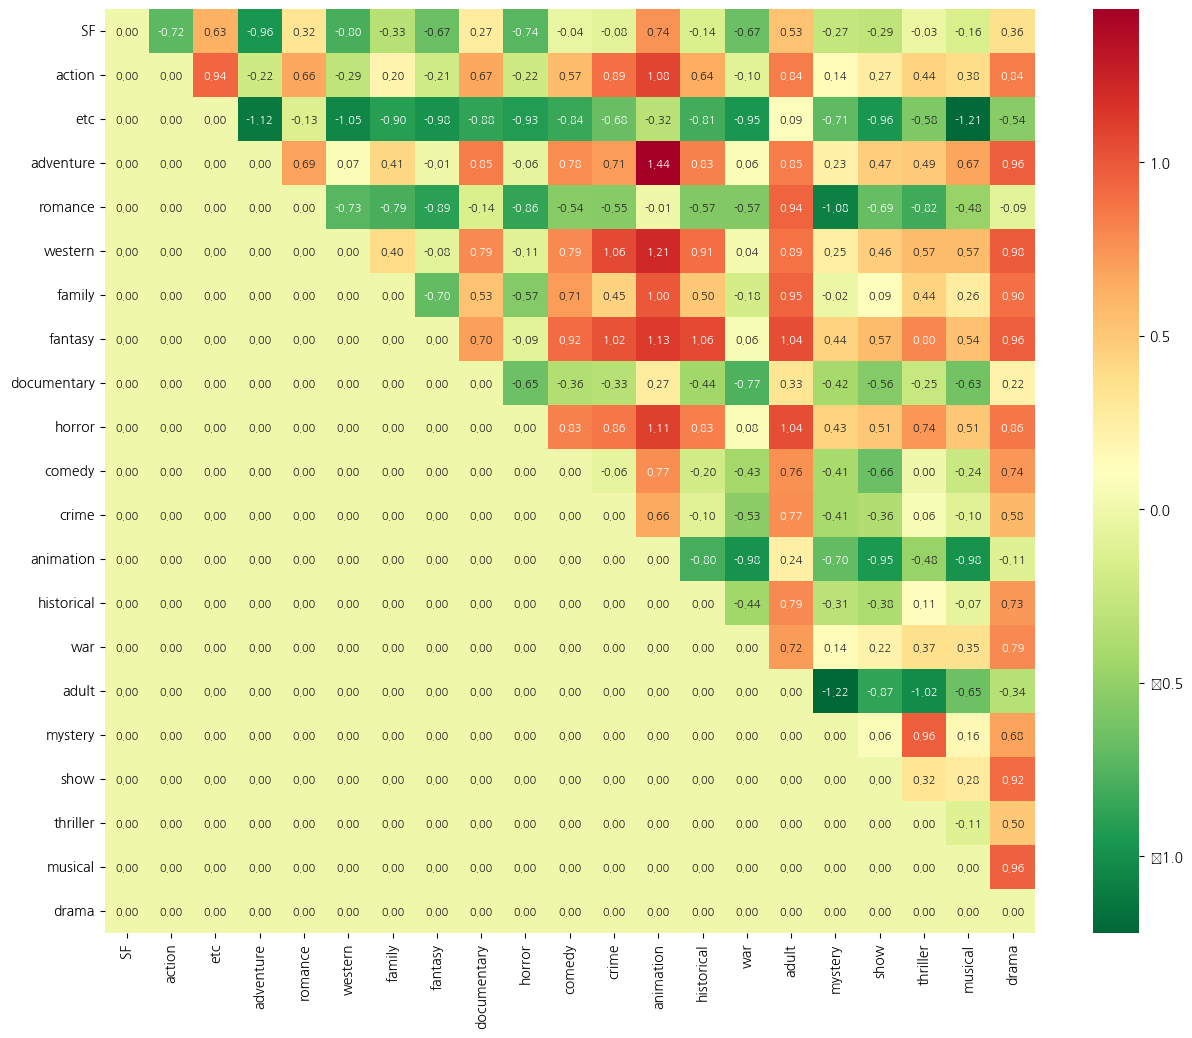

In [71]:
# 1. 캔버스 크기 설정 (가로 15인치, 세로 12인치)
plt.figure(figsize=(15, 12))

# 2. 히트맵 그리기
ax = sns.heatmap(new_matrix, 
                 xticklabels=genre_name, 
                 yticklabels=genre_name, 
                 annot=True, 
                 fmt='.2f',      # 소수점 둘째 자리까지 표시 (글자 겹침 방지)
                 annot_kws={"size": 8}, # 숫자 글자 크기 조절
                 cmap='RdYlGn_r')

plt.show()

결과  
- 오히려 이전보다 더 반대 방향으로 움직인 것 같음
- 희소하게 등장한 단어에 더 가중치를 부여한 게 오히려, target과의 유사도를 떨어뜨려서 더 멀리 향하게 만든 것으로 보임

# 회고

- 데이터가 생각보다 많아서 코드가 돌아가는데 힘들어했다. output을 생각없이 그냥 출력했다가 에디터가 freeze되는 경우가 종종 발생해서, 생각없이 바로 output을 찍어보면 안 된다는 것을 실감했다.
- 또한 위와 같은 상황이 발생한 직후 다시 작업하기 위해 코드를 열려고 했는데 ipynb 파일의 용량이 너무 크다고 에디터에서 열리지 않는 문제가 발생하였다. 원인을 찾아보니 ipynb 파일이 json 형태로 기록된다는 것과, 출력한 output 데이터 역시 json에 기록되어 파일 자체의 용량을 증가시켜 문제가 발생한 것임을 알게 되었다.